<a href="https://colab.research.google.com/github/samriddhisingh05/1BM23CS295_Samriddhi_Singh_ML_Lab/blob/main/1BM23CS295_Lab_5_KNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [5]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Load dataset
data = pd.read_csv ("iris.csv")

# Features and target
X = data.iloc[:, :-1]
y = data.iloc[:, -1]

# Train-test split (80-20)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Choose K value
knn = KNeighborsClassifier(n_neighbors=5)

# Train model
knn.fit(X_train, y_train)

# Prediction
y_pred = knn.predict(X_test)

# Results
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))

Accuracy: 1.0
Confusion Matrix:
 [[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]
Classification Report:
               precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      1.00      1.00         9
   virginica       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



In [9]:
import pandas as pd
import numpy as np
from collections import Counter
from sklearn.model_selection import train_test_split

# Load dataset
data = pd.read_csv("iris.csv")

# Convert species to numbers
data['species'] = data['species'].astype('category').cat.codes

X = data.iloc[:, :-1].values
y = data.iloc[:, -1].values

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

# Distance function
def euclidean_distance(a, b):
    return np.sqrt(np.sum((a - b) ** 2))

# KNN prediction
def knn_predict(X_train, y_train, x, k=5):

    distances = []

    for i in range(len(X_train)):
        d = euclidean_distance(x, X_train[i])
        distances.append((d, y_train[i]))

    distances.sort()

    neighbors = [distances[i][1] for i in range(k)]

    return Counter(neighbors).most_common(1)[0][0]

# Predict all test data
predictions = []

for x in X_test:
    predictions.append(knn_predict(X_train, y_train, x, 5))

# Accuracy
accuracy = np.sum(predictions == y_test) / len(y_test)

print("Accuracy:", accuracy)

# Confusion Matrix
from sklearn.metrics import confusion_matrix
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, predictions))

Accuracy: 0.9666666666666667

Confusion Matrix:
[[11  0  0]
 [ 0  6  0]
 [ 0  1 12]]


In [8]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix

# Load dataset
data = pd.read_csv("diabetes.csv")

# Features and target
X = data.iloc[:, :-1]
y = data.iloc[:, -1]

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Feature scaling
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# KNN model
knn = KNeighborsClassifier(n_neighbors=5)

# Train
knn.fit(X_train, y_train)

# Predict
y_pred = knn.predict(X_test)

# Results
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

Accuracy: 0.6948051948051948
Confusion Matrix:
 [[79 20]
 [27 28]]


In [14]:
import pandas as pd
import numpy as np
from collections import Counter
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix

# Load dataset
data = pd.read_csv("diabetes.csv")

X = data.iloc[:, :-1].values
y = data.iloc[:, -1].values

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

# Feature scaling
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Distance
def euclidean_distance(a, b):
    return np.sqrt(np.sum((a - b) ** 2))

# KNN
def knn_predict(X_train, y_train, x, k=5):

    distances = []

    for i in range(len(X_train)):
        d = euclidean_distance(x, X_train[i])
        distances.append((d, y_train[i]))

    distances.sort()

    neighbors = [distances[i][1] for i in range(k)]

    return Counter(neighbors).most_common(1)[0][0]

# Prediction
predictions = []

for x in X_test:
    predictions.append(knn_predict(X_train, y_train, x, 5))

# Accuracy
accuracy = np.sum(predictions == y_test) / len(y_test)

print("Accuracy:", accuracy)

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, predictions))

Accuracy: 0.7402597402597403

Confusion Matrix:
[[85 13]
 [27 29]]


Best K: 5
Accuracy: 0.639344262295082

Classification Report:

              precision    recall  f1-score   support

           0       0.64      0.55      0.59        29
           1       0.64      0.72      0.68        32

    accuracy                           0.64        61
   macro avg       0.64      0.64      0.63        61
weighted avg       0.64      0.64      0.64        61



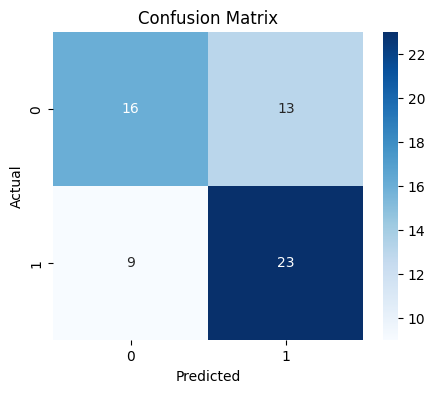

In [19]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Load dataset
data = pd.read_csv("heart.csv")

# Features and target
X = data.drop("target", axis=1)
y = data["target"]

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

# Find best K
scores = []
for k in range(1,21):
    model = KNeighborsClassifier(n_neighbors=k)
    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    scores.append(accuracy_score(y_test, pred))

best_k = scores.index(max(scores)) + 1
print("Best K:", best_k)

# Train final model
knn = KNeighborsClassifier(n_neighbors=best_k)
knn.fit(X_train, y_train)

y_pred = knn.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Plot confusion matrix
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

Best K: 5
Accuracy: 0.7213114754098361

Confusion Matrix:
[[17.  7.]
 [10. 27.]]


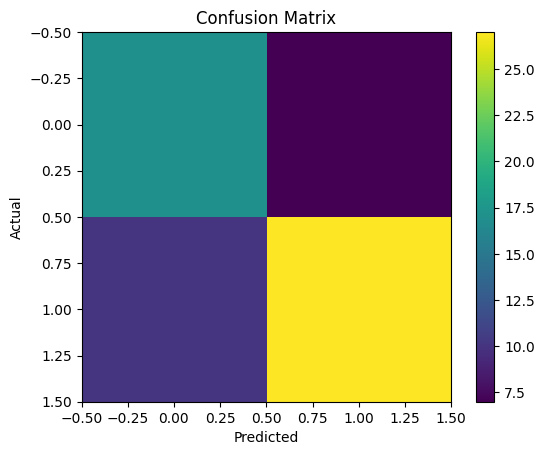

In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter
from sklearn.model_selection import train_test_split

# Load dataset
data = pd.read_csv("heart.csv")

X = data.drop("target", axis=1).values
y = data["target"].values

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

# Euclidean distance
def distance(a,b):
    return np.sqrt(np.sum((a-b)**2))

# KNN function
def knn(x,k):
    dist=[]
    for i in range(len(X_train)):
        d = distance(x,X_train[i])
        dist.append((d,y_train[i]))

    dist.sort()
    neighbors=[dist[i][1] for i in range(k)]
    return Counter(neighbors).most_common(1)[0][0]

# Find best K
best_k=1
best_acc=0

for k in range(1,11):

    pred=[]
    for x in X_test:
        pred.append(knn(x,k))

    acc=np.sum(pred==y_test)/len(y_test)

    if acc>best_acc:
        best_acc=acc
        best_k=k

print("Best K:",best_k)
print("Accuracy:",best_acc)

# Final prediction
pred=[]
for x in X_test:
    pred.append(knn(x,best_k))

# Confusion matrix
cm=np.zeros((2,2))

for i in range(len(y_test)):
    cm[y_test[i]][pred[i]]+=1

print("\nConfusion Matrix:")
print(cm)

# Plot confusion matrix
plt.imshow(cm)
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.colorbar()
plt.show()